# Tb Threshold Interactive Analysis

This notebook lets you interactively analyze brightness temperature (Tb) thresholds
for any cube and year combination, without needing to run the full HPC pipeline.

### This code is created to be used for the supercomputer, but it can be modified for any other machine. It works based on the cubes produced by Molly.
---

## How to use this notebook

1. **Section 1** : Set up imports (run once)
2. **Section 2** : Configure your cube and years (edit the values here)
3. **Section 3** : Load the cube data
4. **Section 4A** : Single-year analysis (histogram + threshold for one year)
5. **Section 4B** : Cumulative analysis (all years pooled together)
6. **Section 5** : Save results to CSV
7. **Section 6** : ROI Analysis (algorithm only, saves CSV)
8. **Section 7** : Convert ROI CSV to GeoTIFF

---
> **Run cells in order top to bottom.** Each section depends on the previous one.

# Required custom scripts (The ones that the notebook imports):

1. CETB_IO.py >> provides read_Tb_whole, years_for, find_cube_offset
2. CETB_algorithmsMB_Final.py >> provides extract_relevant_data, compute_smoothed_histogram, analyze_histogram, analyze_and_segment_histogram

## Required data files:
3. SnowClass_Global_1km.nc >> global snow classification raster
## The notebook itself:
4. Tb_Interactive_Analysis.ipynb

## 1. Imports
Run these cells once at the start of every session.

In [6]:
import os

# --- Fix PROJ_LIB for cetb environment ---
os.environ["PROJ_LIB"]  = "/projects/mabo7890/software/anaconda/envs/cetb/share/proj"
os.environ["GDAL_DATA"] = "/projects/mabo7890/software/anaconda/envs/cetb/share/gdal"

print("PROJ_LIB set to:", os.environ["PROJ_LIB"])

PROJ_LIB set to: /projects/mabo7890/software/anaconda/envs/cetb/share/proj


In [7]:
import os
import csv
import glob
import logging

import numpy as np
import pandas as pd
import rasterio
import xarray as xr
import matplotlib.pyplot as plt
from rasterio.transform import Affine
from pyproj import Transformer

# Set up logging so you can see what is happening
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
log = logging.getLogger(__name__)

# ---- Paths (do not change unless you move files) ----
os.chdir("/projects/mabo7890/Melt_Codes/scripts")

from CETB_IO import read_Tb_whole, years_for, find_cube_offset
from CETB_algorithmsMB_Final import (
    extract_relevant_data,
    compute_smoothed_histogram,
    analyze_histogram,
    analyze_and_segment_histogram,
)

# ---- Transformers ----
to_ease   = Transformer.from_crs("EPSG:4326", "EPSG:6931", always_xy=True)
to_latlon = Transformer.from_crs("EPSG:6931", "EPSG:4326", always_xy=True)

# ---- Snow class categories ----
categories = {
    1: "Tundra",
    2: "Boreal Forest",
    3: "Maritime",
    4: "Ephemeral",
    5: "Prairie",
    6: "Montane Forest",
    7: "Ice",
    8: "Ocean",
}

print("Imports successful — ready to go!")

Imports successful — ready to go!


## 2. Configuration >> Edit This Cell

This is the only cell you need to edit. Set your cube and years here.

| Parameter | What it means |
|-----------|---------------|
| `region` | Cube folder name, e.g. `"N25_44"` |
| `sat_SIR` | Satellite: `"F13"` (SSMI) or `"F16"` (SSMIS) |
| `sensor_SIR` | Sensor: `"SSMI"` or `"SSMIS"` |
| `year_single` | The single year for Section 4A analysis |
| `year_list` | All years to include in Section 4B cumulative analysis |
| `pixel_lat_input`, `pixel_lon_input` | The specific pixel (lat, lon) to analyze |


In [8]:
# ============================================================
#  EDIT THESE VALUES
# ============================================================

# --- Cube to analyze ---
region    = "N25_44"   # e.g. N25_44, N25_43, N25_d34 ...
SiteLabel = "Cube44"   # used in output filenames

# --- Satellite / Sensor ---
sat_SIR     = "F13"    # F13 = SSMI (1995-2009) | F16 = SSMIS (2005-2019)
sensor_SIR  = "SSMI"   # SSMI or SSMIS
channel_SIR = "37V"
alg_SIR     = "SIR"
hemName     = "N"

# --- Single year for Section 4A ---
year_single = 2003     # change to any year in your record

# --- All years for Section 4B cumulative analysis ---
# You can list specific years or use years_for() to get all years automatically
all_years  = years_for(sat_SIR)        # all available years for this satellite
year_list  = list(all_years[0:15])     # change [0:15] to [0:] for ALL years
                                        #    or manually list: [1995, 1996, 1997]

# --- Pixel to analyze (lat/lon — easier than row/col) ---
pixel_lat_input = 60.5    # enter your latitude  (°N)
pixel_lon_input = -135.0  # enter your longitude (°E, negative = West)

# --- Output directory ---
OutDir = "/scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive"
os.makedirs(OutDir, exist_ok=True)

# --- Paths (auto-built from above, do not edit) ---
dataDir     = "/pl/active/PMESDR/CETB_cubesv2"
if sensor_SIR in ["SSMI", "SSMIS"]:
    provider = "L1C"
    version  = "v2.*"

datadir_SIR = f"{dataDir}/{sat_SIR}_{sensor_SIR}/{hemName}/nc_cubes/cubes_{region}/"
prefix_SIR  = f"CETB.cubefile.{region}.{sat_SIR}_{sensor_SIR}-{channel_SIR}-{alg_SIR}-{provider}-{version}"
snowclass_path = "/projects/mabo7890/Melt_Codes/SnowClass_Global_1km.nc"
SEG_BIN_RANGE  = (150, 350)

# ============================================================
print(f" Cube        : {region}  ({SiteLabel})")
print(f" Satellite   : {sat_SIR} / {sensor_SIR}")
print(f" Single year : {year_single}")
print(f" Year list   : {year_list[0]} → {year_list[-1]}  ({len(year_list)} years)")
print(f" Pixel       : row={pixel_lat_input}, col={pixel_lon_input}")
print(f" Output dir  : {OutDir}")

 Cube        : N25_44  (Cube44)
 Satellite   : F13 / SSMI
 Single year : 2003
 Year list   : 1995 → 2009  (15 years)
 Pixel       : row=60.5, col=-135.0
 Output dir  : /scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive


## 3. Load Cube Data

This reads the Tb data for the cube and all years you selected.
It also loads the snow class for each pixel.

> This may take a minute or two depending on cube size.

In [9]:
# --- Get cube spatial extent ---
find_cube_offset(region, cubeDir=datadir_SIR, cubeType=f"{channel_SIR}-{alg_SIR}", verbose=False)

sir_files = sorted(glob.glob(os.path.join(datadir_SIR, f"{prefix_SIR}*.nc")))
if not sir_files:
    raise FileNotFoundError(f"No .nc files found in {datadir_SIR}")
print(f"Found {len(sir_files)} .nc files in cube directory")

ds = xr.open_dataset(sir_files[0])
ny, nx = ds.sizes["y"], ds.sizes["x"]
lat2d  = ds["latitude"].values
lon2d  = ds["longitude"].values
ds.close()

print(f"\n Cube grid size : {ny} rows x {nx} cols = {ny*nx:,} pixels")
print(f" Lat range      : {lat2d.min():.2f}°N → {lat2d.max():.2f}°N")
print(f" Lon range      : {lon2d.min():.2f}°E → {lon2d.max():.2f}°E")

# --- Find nearest pixel to the requested lat/lon ---
# Compute distance from every pixel to the requested point
dist = np.sqrt((lat2d - pixel_lat_input)**2 + (lon2d - pixel_lon_input)**2)
pixel_row, pixel_col = np.unravel_index(np.argmin(dist), dist.shape)

pixel_lat = lat2d[pixel_row, pixel_col]
pixel_lon = lon2d[pixel_row, pixel_col]

print(f"\n Requested      : Lat={pixel_lat_input}°N  Lon={pixel_lon_input}°E")
print(f" Nearest pixel  : row={pixel_row}, col={pixel_col}")
print(f"   Actual Lat={pixel_lat:.4f}°N   Lon={pixel_lon:.4f}°E")
print(f"   Distance to requested point: {dist[pixel_row, pixel_col]:.4f}°")

# Warn if the nearest pixel is far from the request
if dist[pixel_row, pixel_col] > 1.0:
    print(f"  WARNING: Nearest pixel is more than 1° away from your requested location!")
    print(f"   Check that your lat/lon is within this cube's coverage.")

# --- Load snow class for this pixel ---
ds_snow    = xr.open_dataset(snowclass_path)
snow_val   = ds_snow["SnowClass"].sel(
    lat=pixel_lat, lon=pixel_lon, method="nearest"
).values
ds_snow.close()
snow_class = categories.get(int(snow_val), "Unknown")
print(f"   Snow Class = {snow_class} (code={int(snow_val)})")

# --- Load only a small spatial window around the selected pixel ---
row_margin = 2
col_margin = 2

r0 = max(0,  pixel_row - row_margin)
r1 = min(ny, pixel_row + row_margin + 1)
c0 = max(0,  pixel_col - col_margin)
c1 = min(nx, pixel_col + col_margin + 1)

print(f"\n Loading TB data for years {year_list[0]}-{year_list[-1]}...")
print(f"   Spatial subset: rows {r0}:{r1}, cols {c0}:{c1} (5x5 window around pixel)")

data_SIR  = read_Tb_whole(
    datadir_SIR, prefix_SIR, year_list,
    r0, r1, c0, c1,
)
TB        = np.asarray(data_SIR["TB"])
cal_date  = data_SIR["cal_date"]
cal_year  = data_SIR["cal_year"]
cal_month = data_SIR["cal_month"]

print(f" TB loaded: {TB.shape[0]} time steps, {TB.shape[1]} rows, {TB.shape[2]} cols")

# --- Extract time series ---
pixel_row_local = pixel_row - r0
pixel_col_local = pixel_col - c0

tb_series  = TB[:, pixel_row_local, pixel_col_local]
Tb_nearest = pd.DataFrame({"TB": tb_series}, index=cal_date)

print(f"\n TB time series for pixel ({pixel_row},{pixel_col}):")
print(f"   Valid observations : {(~np.isnan(tb_series)).sum():,} / {len(tb_series):,}")
print(f"   TB range           : {np.nanmin(tb_series):.2f} K → {np.nanmax(tb_series):.2f} K")

Reading offset information from cubeFile=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.2008.TB.nc...
Found 60 .nc files in cube directory

 Cube grid size : 640 rows x 640 cols = 409,600 pixels
 Lat range      : 51.25°N → 77.29°N
 Lon range      : -161.53°E → -108.47°E

 Requested      : Lat=60.5°N  Lon=-135.0°E
 Nearest pixel  : row=223, col=223
   Actual Lat=60.5100°N   Lon=-135.0000°E
   Distance to requested point: 0.0100°
   Snow Class = Boreal Forest (code=2)

 Loading TB data for years 1995-2009...
   Spatial subset: rows 221:226, cols 221:226 (5x5 window around pixel)
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1995.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1996.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25

## 4A. Single-Year Analysis

Compute and visualize the histogram and Tb threshold for **one specific year**.

> Change `year_single` in Section 2 to analyze a different year, then re-run this cell.

  Single-Year Analysis: 2003
  Pixel: Lat=60.5100°N  Lon=-135.0000°E
  (row=223, col=223)
  Snow class: Boreal Forest

Data points for year 2003: 540

  Start of Range (251.00 K) falls after Tb Threshold (249.00 K) — replacing with threshold value.

 Results for year 2003:
   Location      : Lat=60.5100°N  Lon=-135.0000°E
   Tb Threshold  : 249
   Start of Range: 249
   End of Range  : 256


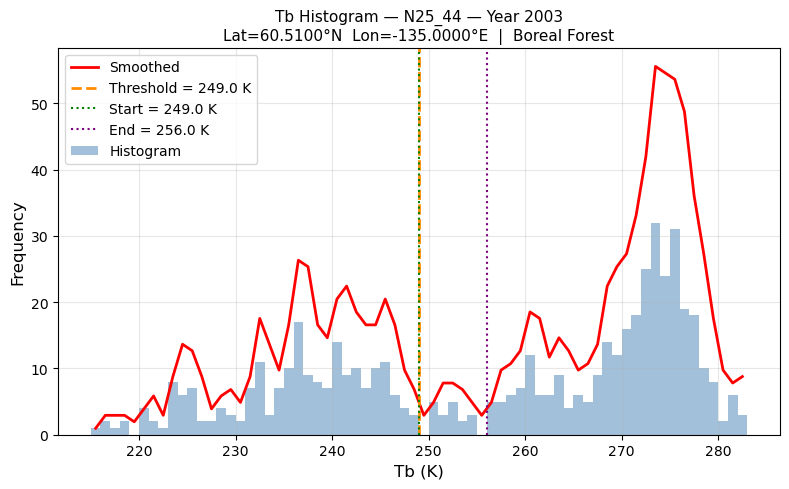


 Plot saved to /scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive


In [10]:
print(f"=" * 55)
print(f"  Single-Year Analysis: {year_single}")
print(f"  Pixel: Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"  (row={pixel_row}, col={pixel_col})")
print(f"  Snow class: {snow_class}")
print(f"=" * 55)

if year_single not in year_list:
    raise ValueError(f"year_single={year_single} is not in year_list={year_list}. "
                     "Add it to year_list in Section 2.")

# --- Filter data to single year ---
Site_label = f"{pixel_row},{pixel_col}"
data_single = extract_relevant_data(
    Tb_nearest, [year_single], cal_year, cal_month, snow_class, Site_label
)
print(f"\nData points for year {year_single}: {len(data_single)}")

# --- Compute histogram ---
hist, bin_edges, hist_smooth = compute_smoothed_histogram(
    data_single, snow_class, Site_label
)

# --- Analyze histogram ---
out_single = analyze_histogram(
    hist, bin_edges, hist_smooth, data_single,
    Site_label, [year_single], sensor_SIR, channel_SIR, snow_class, OutDir
)

# --- Segmentation ---
seg_single = analyze_and_segment_histogram(
    data=data_single, Site=Site_label, year=[year_single],
    snow_class=snow_class, ThresholdDir=OutDir,
    bin_range=SEG_BIN_RANGE, plot=False
)

threshold_single = out_single.get("threshold", None)
start_range      = seg_single.get("effective_end_peak1",   None) if seg_single else None
end_range        = seg_single.get("effective_start_peak2", None) if seg_single else None

# --- Correction: if start_range falls after threshold, replace with threshold ---
if start_range is not None and threshold_single is not None:
    if start_range > threshold_single:
        print(f"\n  Start of Range ({start_range:.2f} K) falls after "
              f"Tb Threshold ({threshold_single:.2f} K) — replacing with threshold value.")
        start_range = threshold_single

print(f"\n Results for year {year_single}:")
print(f"   Location      : Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"   Tb Threshold  : {threshold_single}")
print(f"   Start of Range: {start_range}")
print(f"   End of Range  : {end_range}")

# --- Plot histogram ---
fig, ax = plt.subplots(figsize=(8, 5))
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
ax.bar(bin_centres, hist, width=np.diff(bin_edges),
       alpha=0.5, color="steelblue", label="Histogram")
ax.plot(bin_centres, hist_smooth, "r-", linewidth=2, label="Smoothed")
if threshold_single:
    ax.axvline(threshold_single, color="darkorange", linewidth=2,
               linestyle="--", label=f"Threshold = {threshold_single:.1f} K")
if start_range:
    ax.axvline(start_range, color="green", linewidth=1.5,
               linestyle=":", label=f"Start = {start_range:.1f} K")
if end_range:
    ax.axvline(end_range, color="purple", linewidth=1.5,
               linestyle=":", label=f"End = {end_range:.1f} K")
ax.set_xlabel("Tb (K)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(
    f"Tb Histogram — {region} — Year {year_single}\n"
    f"Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E  |  {snow_class}",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(
    os.path.join(OutDir, f"histogram_{region}_{year_single}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print(f"\n Plot saved to {OutDir}")

## 4B. Cumulative Analysis >> All Years Pooled

Compute and visualize the histogram and Tb threshold using **all years pooled together**.
This is the same approach used in the full HPC pipeline.

> This gives a more stable threshold because it uses more data points.

  Cumulative Analysis: 1995–2009
  Pixel: Lat=60.5100°N  Lon=-135.0000°E
  (row=223, col=223)
  Snow class: Boreal Forest

Total data points across all years: 7389

 Results for all years 1995–2009:
   Location      : Lat=60.5100°N  Lon=-135.0000°E
   Tb Threshold  : 253
   Start of Range: 249
   End of Range  : 259


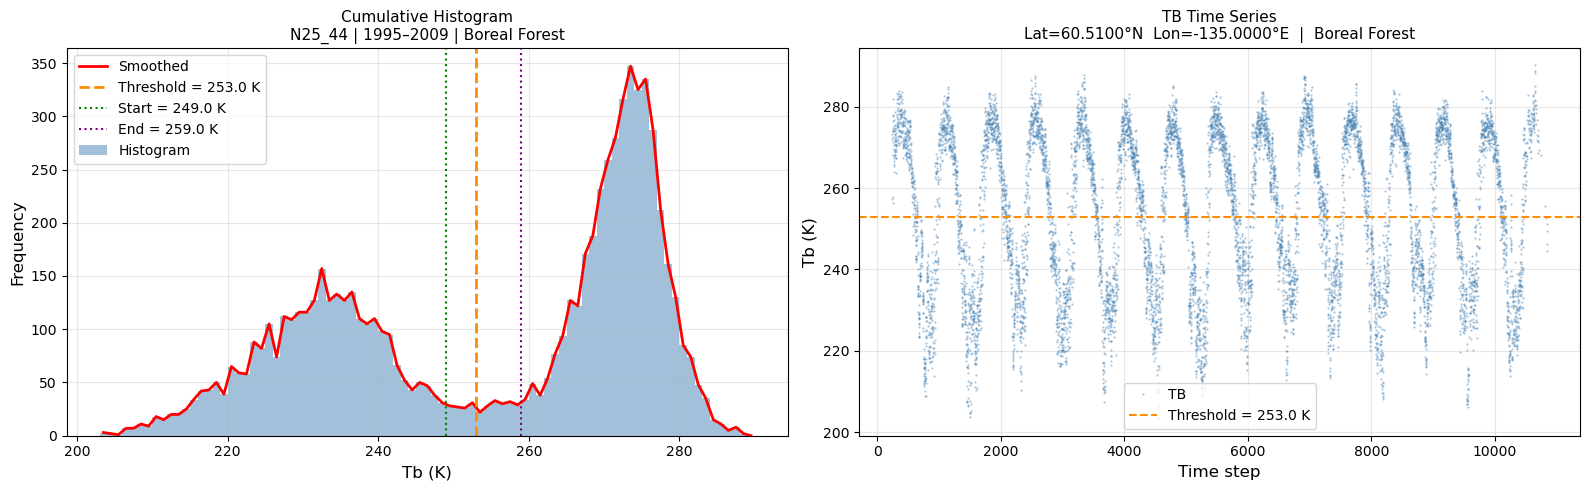


 Plot saved to /scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive

  Comparison Summary
                           Single year       Cumulative
  Year(s)                         2003        1995-2009
  Location                   Lat=60.51       Lon=-135.0
  Tb Threshold (K)                 249              253
  Start of Range (K)               249              249
  End of Range (K)                 256              259


In [11]:
print(f"=" * 55)
print(f"  Cumulative Analysis: {year_list[0]}–{year_list[-1]}")
print(f"  Pixel: Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"  (row={pixel_row}, col={pixel_col})")
print(f"  Snow class: {snow_class}")
print(f"=" * 55)

Site_label = f"{pixel_row},{pixel_col}"

# --- Filter data using all years ---
data_all = extract_relevant_data(
    Tb_nearest, year_list, cal_year, cal_month, snow_class, Site_label
)
print(f"\nTotal data points across all years: {len(data_all)}")

# --- Compute histogram ---
hist_all, bin_edges_all, hist_smooth_all = compute_smoothed_histogram(
    data_all, snow_class, Site_label
)

# --- Analyze histogram ---
out_all = analyze_histogram(
    hist_all, bin_edges_all, hist_smooth_all, data_all,
    Site_label, year_list, sensor_SIR, channel_SIR, snow_class, OutDir
)

# --- Segmentation ---
seg_all = analyze_and_segment_histogram(
    data=data_all, Site=Site_label, year=year_list,
    snow_class=snow_class, ThresholdDir=OutDir,
    bin_range=SEG_BIN_RANGE, plot=False
)

threshold_all = out_all.get("threshold", None)
start_all     = seg_all.get("effective_end_peak1",   None) if seg_all else None
end_all       = seg_all.get("effective_start_peak2", None) if seg_all else None

# --- Correction: if start_all falls after threshold, replace with threshold ---
if start_all is not None and threshold_all is not None:
    if start_all > threshold_all:
        print(f"\n  Start of Range ({start_all:.2f} K) falls after "
              f"Tb Threshold ({threshold_all:.2f} K) — replacing with threshold value.")
        start_all = threshold_all

print(f"\n Results for all years {year_list[0]}–{year_list[-1]}:")
print(f"   Location      : Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"   Tb Threshold  : {threshold_all}")
print(f"   Start of Range: {start_all}")
print(f"   End of Range  : {end_all}")

# --- Plot histogram ---
bin_centres_all = (bin_edges_all[:-1] + bin_edges_all[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cumulative histogram
ax = axes[0]
ax.bar(bin_centres_all, hist_all, width=np.diff(bin_edges_all),
       alpha=0.5, color="steelblue", label="Histogram")
ax.plot(bin_centres_all, hist_smooth_all, "r-", linewidth=2, label="Smoothed")
if threshold_all:
    ax.axvline(threshold_all, color="darkorange", linewidth=2,
               linestyle="--", label=f"Threshold = {threshold_all:.1f} K")
if start_all:
    ax.axvline(start_all, color="green", linewidth=1.5,
               linestyle=":", label=f"Start = {start_all:.1f} K")
if end_all:
    ax.axvline(end_all, color="purple", linewidth=1.5,
               linestyle=":", label=f"End = {end_all:.1f} K")
ax.set_xlabel("Tb (K)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title(
    f"Cumulative Histogram\n"
    f"{region} | {year_list[0]}–{year_list[-1]} | {snow_class}",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: TB time series
ax2 = axes[1]
ax2.plot(range(len(tb_series)), tb_series, ".", markersize=1,
         color="steelblue", alpha=0.5, label="TB")
if threshold_all:
    ax2.axhline(threshold_all, color="darkorange", linewidth=1.5,
                linestyle="--", label=f"Threshold = {threshold_all:.1f} K")
ax2.set_xlabel("Time step", fontsize=12)
ax2.set_ylabel("Tb (K)", fontsize=12)
ax2.set_title(
    f"TB Time Series\n"
    f"Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E  |  {snow_class}",
    fontsize=11
)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(
    os.path.join(OutDir, f"cumulative_{region}_{year_list[0]}-{year_list[-1]}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print(f"\n Plot saved to {OutDir}")

# --- Comparison summary ---
print(f"\n{'='*55}")
print(f"  Comparison Summary")
print(f"{'='*55}")
print(f"  {'':20s} {'Single year':>15s}  {'Cumulative':>15s}")
print(f"  {'Year(s)':20s} {str(year_single):>15s}  {str(year_list[0])+'-'+str(year_list[-1]):>15s}")
print(f"  {'Location':20s} {'Lat='+str(round(pixel_lat,2)):>15s}  {'Lon='+str(round(pixel_lon,2)):>15s}")
print(f"  {'Tb Threshold (K)':20s} {str(round(threshold_single,2) if threshold_single else 'N/A'):>15s}  {str(round(threshold_all,2) if threshold_all else 'N/A'):>15s}")
print(f"  {'Start of Range (K)':20s} {str(round(start_range,2) if start_range else 'N/A'):>15s}  {str(round(start_all,2) if start_all else 'N/A'):>15s}")
print(f"  {'End of Range (K)':20s} {str(round(end_range,2) if end_range else 'N/A'):>15s}  {str(round(end_all,2) if end_all else 'N/A'):>15s}")

## 5. Save Results to CSV

Run this cell to save both the single-year and cumulative results to CSV files.

> The CSV files will be saved to the `OutDir` you set in Section 2.

In [13]:
# Choose which result to save to CSV:
# 'single' = Section 4A result (one year)
# 'cumulative' = Section 4B result (all years pooled)
# 'both' = save both
SAVE_MODE = "both"   #  change to 'single' or 'cumulative' if needed

header = ["Site", "Snow Class", "Latitude", "Longitude",
          "x", "y", "Tb Threshold", "StartofRange", "EndofRange"]

row_data = [
    f"{pixel_row},{pixel_col}",
    snow_class,
    pixel_lat,
    pixel_lon,
    pixel_col,
    pixel_row,
]

if SAVE_MODE in ("single", "both"):
    csv_single = os.path.join(
        OutDir,
        f"TbThresholds_{year_single}_{sensor_SIR}_{SiteLabel}_{region}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.csv"
    )
    with open(csv_single, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerow(row_data + [threshold_single, start_range, end_range])
    print(f" Single-year CSV saved:\n   {csv_single}")

if SAVE_MODE in ("cumulative", "both"):
    csv_cumul = os.path.join(
        OutDir,
        f"TbThresholds_{year_list[0]}-{year_list[-1]}_{sensor_SIR}_{SiteLabel}_{region}_lat{pixel_lat:.2f}_lon{pixel_lon:.2f}.csv"
    )
    with open(csv_cumul, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerow(row_data + [threshold_all, start_all, end_all])
    print(f" Cumulative CSV saved:\n   {csv_cumul}")

print("\n Summary of saved values:")
print(f"   Location     : Lat={pixel_lat:.4f}°N  Lon={pixel_lon:.4f}°E")
print(f"   Pixel        : row={pixel_row}, col={pixel_col}")
print(f"   Snow class   : {snow_class}")
if SAVE_MODE in ("single", "both"):
    print(f"   [{year_single}] Threshold={threshold_single}  Start={start_range}  End={end_range}")
if SAVE_MODE in ("cumulative", "both"):
    print(f"   [All years]  Threshold={threshold_all}  Start={start_all}  End={end_all}")

 Single-year CSV saved:
   /scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive/TbThresholds_2003_SSMI_Cube44_N25_44_lat60.51_lon-135.00.csv
 Cumulative CSV saved:
   /scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive/TbThresholds_1995-2009_SSMI_Cube44_N25_44_lat60.51_lon-135.00.csv

 Summary of saved values:
   Location     : Lat=60.5100°N  Lon=-135.0000°E
   Pixel        : row=223, col=223
   Snow class   : Boreal Forest
   [2003] Threshold=249  Start=249  End=256
   [All years]  Threshold=253  Start=249  End=259


## 6. ROI Analysis (algorithm only, saves CSV):

In [14]:
# ============================================================
#  Region of Interest Analysis
# ============================================================

# --- Define your region of interest ---
ROI_lat_min = 58.0    #  southern boundary (°N)
ROI_lat_max = 58.3    #  northern boundary (°N)
ROI_lon_min = -131.0  #  western boundary  (°E, negative = West)
ROI_lon_max = -130.0  #  eastern boundary  (°E)

# 'single' = use year_single only | 'cumulative' = use all years in year_list
ROI_MODE = "cumulative"   #  change if needed

print(f"=" * 55)
print(f"  Region of Interest Analysis")
print(f"  Lat: {ROI_lat_min}°N → {ROI_lat_max}°N")
print(f"  Lon: {ROI_lon_min}°E → {ROI_lon_max}°E")
print(f"  Mode: {ROI_MODE}")
print(f"=" * 55)

# --- Find all pixels within the bounding box ---
roi_mask = (
    (lat2d >= ROI_lat_min) & (lat2d <= ROI_lat_max) &
    (lon2d >= ROI_lon_min) & (lon2d <= ROI_lon_max)
)
roi_rows, roi_cols = np.where(roi_mask)

if len(roi_rows) == 0:
    raise ValueError("No pixels found in the specified region. "
                     "Check your lat/lon bounds are within this cube's coverage.")

print(f"\n Pixels found in ROI: {len(roi_rows):,}")
print(f"   Row range : {roi_rows.min()} → {roi_rows.max()}")
print(f"   Col range : {roi_cols.min()} → {roi_cols.max()}")

# --- Load TB data for the ROI bounding box only ---
r0_roi = int(roi_rows.min())
r1_roi = int(roi_rows.max()) + 1
c0_roi = int(roi_cols.min())
c1_roi = int(roi_cols.max()) + 1

roi_years = [year_single] if ROI_MODE == "single" else year_list

print(f"\n Loading TB data for ROI subset...")
print(f"   Rows {r0_roi}:{r1_roi}, Cols {c0_roi}:{c1_roi}")
print(f"   Years: {roi_years[0]}–{roi_years[-1]} ({len(roi_years)} years)")

data_ROI = read_Tb_whole(
    datadir_SIR, prefix_SIR, roi_years,
    r0_roi, r1_roi, c0_roi, c1_roi,
)
TB_roi        = np.asarray(data_ROI["TB"])
cal_date_roi  = data_ROI["cal_date"]
cal_year_roi  = data_ROI["cal_year"]
cal_month_roi = data_ROI["cal_month"]

print(f" TB loaded: {TB_roi.shape[0]} time steps, "
      f"{TB_roi.shape[1]} rows, {TB_roi.shape[2]} cols")

# --- Load snow class for all ROI pixels ---
print(f"\n⏳ Loading snow class for ROI pixels...")
ds_snow_roi = xr.open_dataset(snowclass_path)

# --- Run algorithm for each pixel in ROI ---
print(f"\n Running threshold analysis for {len(roi_rows):,} pixels...")
roi_results = []
n_roi = len(roi_rows)

for k, (pr, pc) in enumerate(zip(roi_rows, roi_cols), start=1):
    lat_px = lat2d[pr, pc]
    lon_px = lon2d[pr, pc]

    snow_val_px = ds_snow_roi["SnowClass"].sel(
        lat=lat_px, lon=lon_px, method="nearest"
    ).values
    snow_class_px = categories.get(int(snow_val_px), "Unknown")

    pr_local = pr - r0_roi
    pc_local = pc - c0_roi

    tb_px    = TB_roi[:, pr_local, pc_local]
    Tb_px_df = pd.DataFrame({"TB": tb_px}, index=cal_date_roi)
    site_px  = f"{pr},{pc}"

    try:
        data_px = extract_relevant_data(
            Tb_px_df, roi_years, cal_year_roi, cal_month_roi,
            snow_class_px, site_px
        )
        hist_px, bin_edges_px, hist_smooth_px = compute_smoothed_histogram(
            data_px, snow_class_px, site_px
        )
        out_px = analyze_histogram(
            hist_px, bin_edges_px, hist_smooth_px, data_px,
            site_px, roi_years, sensor_SIR, channel_SIR,
            snow_class_px, OutDir
        )
        seg_px = analyze_and_segment_histogram(
            data=data_px, Site=site_px, year=roi_years,
            snow_class=snow_class_px, ThresholdDir=OutDir,
            bin_range=SEG_BIN_RANGE, plot=False
        )

        thr_px   = out_px.get("threshold", None)
        start_px = seg_px.get("effective_end_peak1",   None) if seg_px else None
        end_px   = seg_px.get("effective_start_peak2", None) if seg_px else None

        # Correction: if start falls after threshold, replace with threshold
        if start_px is not None and thr_px is not None:
            if start_px > thr_px:
                start_px = thr_px

    except Exception as e:
        thr_px = start_px = end_px = None

    roi_results.append([
        site_px, snow_class_px, lat_px, lon_px,
        pc, pr, thr_px, start_px, end_px
    ])

    if k % 100 == 0:
        print(f"   {k:,}/{n_roi:,} pixels done...")

ds_snow_roi.close()
print(f"\n ROI analysis complete: {len(roi_results):,} pixels processed")

# --- Save ROI results to CSV ---
years_tag = str(roi_years[0]) if ROI_MODE == "single" \
            else f"{roi_years[0]}-{roi_years[-1]}"

csv_roi = os.path.join(
    OutDir,
    f"TbThresholds_{years_tag}_{sensor_SIR}_{SiteLabel}_{region}_"
    f"ROI_lat{ROI_lat_min}-{ROI_lat_max}_lon{ROI_lon_min}-{ROI_lon_max}.csv"
)

with open(csv_roi, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Site", "Snow Class", "Latitude", "Longitude",
                "x", "y", "Tb Threshold", "StartofRange", "EndofRange"])
    w.writerows(roi_results)

print(f" ROI CSV saved:\n   {csv_roi}")

  Region of Interest Analysis
  Lat: 58.0°N → 58.3°N
  Lon: -131.0°E → -130.0°E
  Mode: cumulative

 Pixels found in ROI: 201
   Row range : 220 → 240
   Col range : 96 → 115

 Loading TB data for ROI subset...
   Rows 220:241, Cols 96:116
   Years: 1995–2009 (15 years)
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1995.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1996.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1997.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1998.TB.nc...
Next filename=/pl/active/PMESDR/CETB_cubesv2/F13_SSMI/N/nc_cubes/cubes_N25_44/CETB.cubefile.N25_44.F13_SSMI-37V-SIR-L1C-v2.0.1999.TB.nc...
Next filename=/pl/active/PMESDR/CE

## 7. Convert ROI CSV to GeoTIFF

Convert the saved CSV to a georeferenced GeoTIFF file that you can open in **QGIS or ArcGIS**.

> This creates a box of interest GeoTIFF.

Converting ROI CSV to GeoTIFF...
   Source: TbThresholds_1995-2009_SSMI_Cube44_N25_44_ROI_lat58.0-58.3_lon-131.0--130.0.csv
   Grid size : 20 cols x 21 rows
   x offset  : 96   y offset: 220
   Anchor pixel : x=108, y=220
   West edge    : -2662500 m
   South edge   : 2312500 m

 ROI GeoTIFF saved: /scratch/alpine/mabo7890/Tb_Thresholds_NewCubes/Interactive/TbThresholds_1995-2009_SSMI_Cube44_N25_44_ROI_lat58.0-58.3_lon-131.0--130.0.tif
   Size     : 20 x 21 pixels
   CRS      : EPSG:6931 (EASE-Grid 2.0 North)
   Location : Lat=58.0–58.3°N  Lon=-131.0–-130.0°E


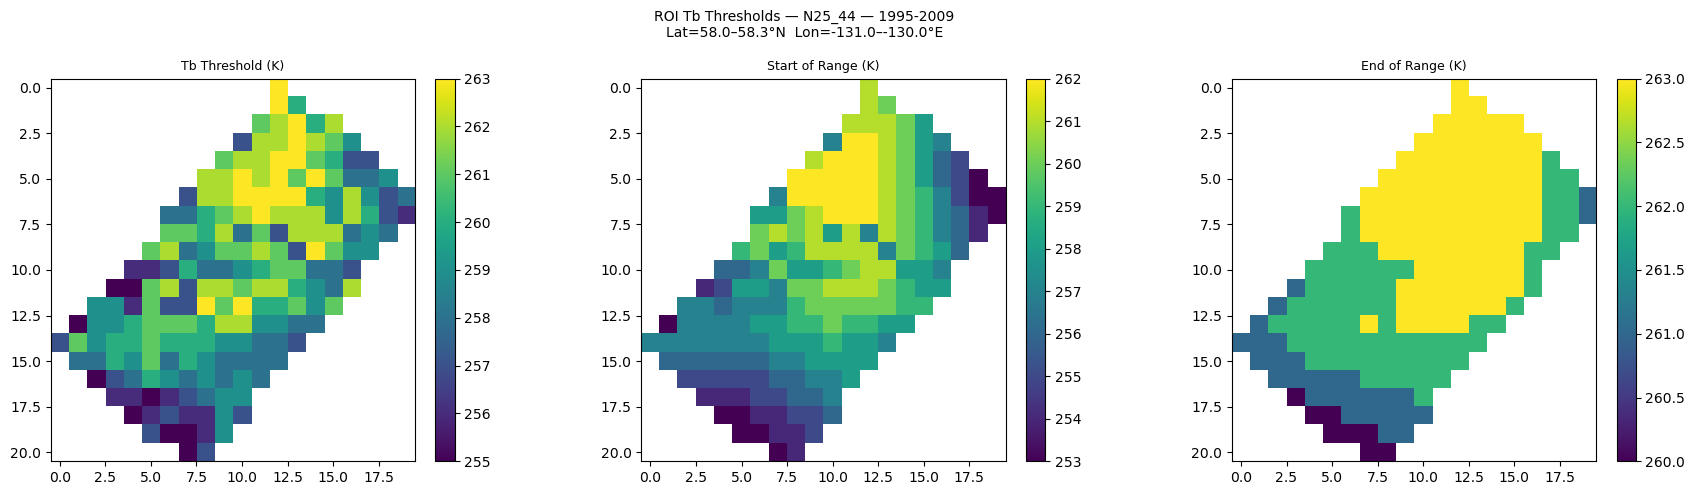

 Preview saved: TbThresholds_1995-2009_SSMI_Cube44_N25_44_ROI_lat58.0-58.3_lon-131.0--130.0_preview.png

 Open the GeoTIFF in QGIS or ArcGIS Pro.


In [15]:
# ============================================================
# Convert ROI CSV to GeoTIFF
# Run this after Cell 4C completes
# ============================================================

print(f"Converting ROI CSV to GeoTIFF...")
print(f"   Source: {os.path.basename(csv_roi)}")

df_roi = pd.read_csv(csv_roi)

# Offset x/y to local indices
x_offset = int(df_roi["x"].min())
y_offset = int(df_roi["y"].min())
nx_roi   = int(df_roi["x"].max()) - x_offset + 1
ny_roi   = int(df_roi["y"].max()) - y_offset + 1

print(f"   Grid size : {nx_roi} cols x {ny_roi} rows")
print(f"   x offset  : {x_offset}   y offset: {y_offset}")

# Build transform from anchor pixel
# Use the pixel with minimum y, then minimum x within that row
y_min_val  = int(df_roi["y"].min())
anchor_row = df_roi[df_roi["y"] == y_min_val].sort_values("x").iloc[0]

x_m_roi, y_m_roi = to_ease.transform(
    float(anchor_row["Longitude"]), float(anchor_row["Latitude"])
)
west_roi  = x_m_roi - 3125.0 / 2
south_roi = y_m_roi + 3125.0 / 2
transform_roi = Affine(3125.0, 0.0, west_roi, 0.0, -3125.0, south_roi)

print(f"   Anchor pixel : x={anchor_row['x']}, y={anchor_row['y']}")
print(f"   West edge    : {west_roi:.0f} m")
print(f"   South edge   : {south_roi:.0f} m")

# Fill grids
grid_thr_roi = np.full((ny_roi, nx_roi), -9999.0, dtype=np.float32)
grid_sta_roi = np.full((ny_roi, nx_roi), -9999.0, dtype=np.float32)
grid_end_roi = np.full((ny_roi, nx_roi), -9999.0, dtype=np.float32)

xi_roi   = df_roi["x"].values.astype(int) - x_offset
yi_roi   = df_roi["y"].values.astype(int) - y_offset
thr_vals = pd.to_numeric(df_roi["Tb Threshold"], errors="coerce").values.astype(float)
sta_vals = pd.to_numeric(df_roi["StartofRange"], errors="coerce").values.astype(float)
end_vals = pd.to_numeric(df_roi["EndofRange"],   errors="coerce").values.astype(float)

grid_thr_roi[yi_roi[~np.isnan(thr_vals)], xi_roi[~np.isnan(thr_vals)]] = thr_vals[~np.isnan(thr_vals)]
grid_sta_roi[yi_roi[~np.isnan(sta_vals)], xi_roi[~np.isnan(sta_vals)]] = sta_vals[~np.isnan(sta_vals)]
grid_end_roi[yi_roi[~np.isnan(end_vals)], xi_roi[~np.isnan(end_vals)]] = end_vals[~np.isnan(end_vals)]

tif_roi = csv_roi.replace(".csv", ".tif")

with rasterio.open(
    tif_roi, "w",
    driver="GTiff", height=ny_roi, width=nx_roi, count=3,
    dtype=np.float32, crs=rasterio.CRS.from_epsg(6931),
    transform=transform_roi, nodata=-9999.0,
    compress="deflate", tiled=True, blockxsize=256, blockysize=256,
) as dst:
    dst.write(grid_thr_roi, 1)
    dst.write(grid_sta_roi, 2)
    dst.write(grid_end_roi, 3)
    dst.update_tags(BAND_1="Tb_Threshold", BAND_2="StartOfRange", BAND_3="EndOfRange")

print(f"\n ROI GeoTIFF saved: {tif_roi}")
print(f"   Size     : {nx_roi} x {ny_roi} pixels")
print(f"   CRS      : EPSG:6931 (EASE-Grid 2.0 North)")
print(f"   Location : Lat={ROI_lat_min}–{ROI_lat_max}°N  Lon={ROI_lon_min}–{ROI_lon_max}°E")

# --- Quick preview plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"ROI Tb Thresholds — {region} — {years_tag}\n"
    f"Lat={ROI_lat_min}–{ROI_lat_max}°N  Lon={ROI_lon_min}–{ROI_lon_max}°E",
    fontsize=10
)
band_names = ["Tb Threshold (K)", "Start of Range (K)", "End of Range (K)"]
grids      = [grid_thr_roi, grid_sta_roi, grid_end_roi]

for ax, grid, name in zip(axes, grids, band_names):
    arr = grid.astype(float)
    arr[arr == -9999.0] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        ax.set_title(f"{name}\n(no valid data)")
        ax.axis("off")
        continue
    vmin = np.percentile(valid, 2)
    vmax = np.percentile(valid, 98)
    im = ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax,
                   interpolation="none", origin="lower")
    ax.invert_yaxis()
    ax.set_title(name, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
preview_roi = tif_roi.replace(".tif", "_preview.png")
plt.savefig(preview_roi, dpi=150, bbox_inches="tight")
plt.show()
print(f" Preview saved: {os.path.basename(preview_roi)}")
print(f"\n Open the GeoTIFF in QGIS or ArcGIS Pro.")